# <span style="color:teal"> Lezione 8 </span>
## <span style="color:turquoise"> Esercizio 8.1 </span>
In questo esercizio abbiamo considerato una particella in uno spazio unidimensionale 1D soggetta a un potenziale $V(x)=x^4-\frac{5}{2}x^2$. Questo sistema quantistico non è risolvibile analiticamente, quindi il nostro obiettivo è stimare la forma della miglior autofunzione relativa allo stato fondamentale, che approssiamo con una doppia gaussiana: $$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$
Per fare ciò sfruttiamo il principio variazionale della meccanica quantistica che afferma che il valore di aspettazione dell'Hamiltoniana ${\hat H}=-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x)$ rispetto a una buona funzione di prova è sempre maggiore o uguale dell'energia dello stato fondamentale $\langle {\hat H} \rangle_T \ge E_0$.  

Realizziamo un codice Monte Carlo Variazionale che implementa l'algoritmo di Metropolis per campionare punti $x$ dalla distribuzione $|\Psi_T^{\sigma,\mu}(x)|^2$. Per ogni punto campionato, il codice calcola l'energia locale $E_L$=$\frac{H \Psi_T(x)}{\Psi_T(x)}$ e ne stima il valor medio tramite il metodo del data blocking, che fornisce una stima ottimale con il corretto errore statistico. Per semplicità utilizziamo unità ridotte $\hbar = 1$ e $m=1$ e fissiamo i parametri variazionali a $\mu = 1.1$, vicino alla posizione dei minimi del potenziale, e $\sigma = 0.5$, dell'ordine della larghezza della buca. 

La proposta di Metropolis è uniforme nell'intervallo $[x - \delta_x, x + \delta_x]$ con $\delta_x = 1.1$, scelto in modo da ottenere un tasso di accettazione vicino al valore ottimale del $50\%$ per distribuzioni unidimensionali. Prima di iniziare la raccolta dati, il sistema viene termalizzato con 1000 passi Metropolis. Vengono svolte $M=10^4$ misure totali suddivise in $N=100$ blocchi.

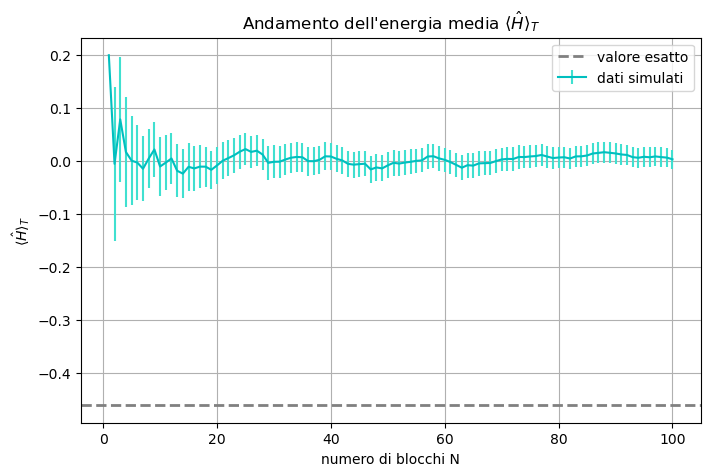

In [1]:
# grafico energia

# ----------- codice per risolvere problema analiticamente ---------------------------------
import numpy as np
import matplotlib.pyplot as plt

def Vpot(x):
    return (x**2 - 2.5)*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# ------------ codice per calcolare soluz analitiche ------------------------------------------------------

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

# ----------- carico e grafico -----------------------------------------------

data = np.loadtxt("Esercizio8.1/energia.dat")
n_block = data[:, 0]
en_prog = data[:, 2]
err_en_prog = data[:,3]

plt.figure(figsize=(8,5))
plt.errorbar(n_block, en_prog, yerr=err_en_prog, color='c', ecolor='turquoise', label='dati simulati')
plt.axhline(y=E[0], ls='--', lw=2, color='grey', label = 'valore esatto')
plt.xlabel("numero di blocchi N")
plt.ylabel(r"$\langle \hat{H} \rangle_T$")
plt.title(r"Andamento dell'energia media $\langle \hat {H} \rangle_T$ ")
plt.grid(True)
plt.legend()
plt.show()

Il grafico mostra il valor medio progressivo di $\langle {\hat H} \rangle_T$ al crescere del numero di blocchi, con le relative barre di errore statistico ottenute tramite data blocking. Il comportamento è quello atteso: le fluttuazioni sono ampie nei primi blocchi e si riducono progressivamente all'aumentare dei dati accumulati, fino a stabilizzarsi intorno a $\langle \hat{H} \rangle_T \approx 0$, confermando che il data blocking funziona correttamente.

Tuttavia, il valore stimato risulta molto lontano dall'energia esatta dello stato fondamentale $E_0 \approx -0.46$ (linea tratteggiata grigia), il che indica che la funzione di prova $\Psi_T^{\sigma,\mu}$ con i parametri scelti $\mu = 1.1$ e $\sigma = 0.5$ non approssima bene lo stato fondamentale del sistema. Questo però non era così inatteso, infatti i valori di $\mu$ e $\sigma$ sono stati fissati a priori sulla base di considerazioni geometriche sul potenziale, senza alcuna ottimizzazione.

## <span style="color:turquoise"> Esercizio 8.2 </span>
L'obiettivo di questo esercizio è ottimizzare la scelta dei parametri variazionali $\mu$ e $\sigma$ che minimizzano $\langle {\hat H} \rangle_T$, estendendo il codice Monte Carlo Variazionale dell'esercizio precedente integrando un algoritmo di Simulated Annealing (SA). Il SA è un metodo di ottimizzazione stocastica ispirato al processo fisico del raffreddamento lento di un solido: a temperature elevate il sistema esplora liberamente lo spazio dei parametri, accettando anche configurazioni peggiori; al diminuire della temperatura, la ricerca si concentra progressivamente attorno al minimo.

Nel nostro caso, $\langle {\hat H} \rangle_T^{\sigma,\mu}$ funge da funzione di costo da minimizzare nello spazio bidimensionale $(\mu, \sigma)$. Ad ogni passo viene proposta una nuova coppia di parametri $(\mu_{\text{trial}}, \sigma_{\text{trial}})$, ottenuta perturbando i parametri correnti con estrazioni uniformi di ampiezza $\delta_\mu = 0.15$ e $\delta_\sigma = 0.08$:
$$ \mu_{\text{trial}} = \mu_{\text{now}}+U(-\delta_{\mu}, + \delta_{\mu}) \qquad \sigma_{\text{trial}} = \sigma_{\text{now}}+U(-\delta_{\sigma}, + \delta_{\sigma})$$


La mossa viene accettata sempre se $\Delta E = \langle \hat{H} \rangle_{\text{trial}} - \langle \hat{H} \rangle_{\text{now}} <0 $, altrimenti con probabilità $e^{-\Delta E / T}$ (peso di Bolzmann). Inoltre, poiché la funzione di prova è simmetrica per $\mu \to -\mu$ e $\sigma$ deve essere fisicamente positiva, eventuali valori negativi proposti vengono riflessi.  

$T$ è una temperatura artificiale, che viene ridotta progressivamente secondo la legge geometrica $T_{n+1} = a \cdot T_n$ con $a = 0.92$, a partire da $T_{\text{start}} = 2.00$ fino a $T_{\text{stop}} = 0.01$. 
Il numero di passi per temperatura cresce al diminuire di $T$, fino a un massimo di 20, per raffinare l'esplorazione nella regione di minimo.

I parametri iniziali sono stati scelti lontani dal minimo atteso $(\mu_{\text{start}} = 2.0,\,\sigma_{\text{start}} = 1.0)$ in modo tale da permettere all'algoritmo di esplorare ampie regioni dello spazio $(\mu, \sigma)$ prima di convergere. Partire da una configurazione già vicina al minimo avrebbe ridotto l'esplorazione e aumentato il rischio di rimanere intrappolati in un minimo locale. Analogamente, anche la temperatura iniziale $T_{\text{start}} = 2.0$ è stata scelta sufficientemente alta da rendere accettabili anche mosse con $\Delta E$ dell'ordine dell'unità, garantendo una fase esplorativa efficace.  

Per ogni configurazione $(\mu_{\text{trial}}, \sigma_{\text{trial}})$ proposta, il valore di $\langle \hat{H} \rangle_T$ viene stimato tramite una simulazione VMC con $M=10000$ misure suddivise in $N=100$ blocchi, dove si è utilizzato $\delta_x=1.1$ per ottenere un'accettanza complessiva attorno al $50\%$.

Infine, una volta individuati i parametri ottimali $(\mu^*, \sigma^*)$, viene eseguita una run VMC finale con $M=20000$ misure suddivise in $N=100$ blocchi, preceduta da 5000 passi di termalizzazione. Qui è stato cambiato $\delta_x=2.65$ per ottenere un'accettanza complessiva attorno al $50\%$, così da realizzare una stima accurata dell'energia minima.  

Le posizioni $x$ visitate durante la simulazione vengono salvate su file: essendo il Metropolis progettato per campionare proprio da $|\Psi_T^{\mu^*,\sigma^*}(x)|^2$, l'istogramma di questi valori riproduce direttamente la densità di probabilità della funzione d'onda ottimizzata.

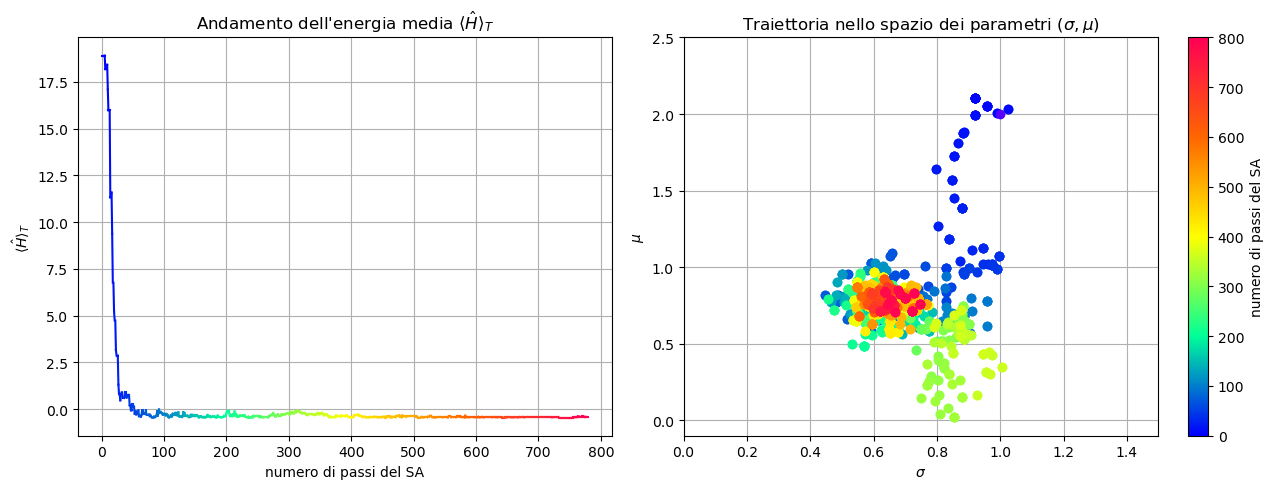

Il valore ottimale di μ è: 0.813034
Il valore ottimale di σ è: 0.614136


In [2]:
# grafico E e sigma-mu di SA

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

data = np.loadtxt("Esercizio8.2/sa_trajectory.dat", skiprows=1)
n_block = data[:, 0]
T_prog = data[:,1]
mu_prog = data[:,2]
sigma_prog = data[:,3]
en_prog = data[:, 4]

data_best = np.loadtxt("Esercizio8.2/best_values.dat")
mu_best, sigma_best = data_best


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [4.5, 5]} )

ax1.set_xlabel("numero di passi del SA")
ax1.set_ylabel(r"$\langle \hat{H} \rangle_T$")
ax1.set_title(r"Andamento dell'energia media $\langle \hat{H} \rangle_T$")
ax1.grid(True)

cmap = mcolors.LinearSegmentedColormap.from_list(
    "arcobaleno_custom", [
        (0.00, "#0000ff"),  # blu
        (0.25, "#00ff99"),  # verde
        (0.50, "#ffff00"),  # giallo
        (0.75, "#ff6600"),  # arancione
        (1.00, "#ff0055"),  # rosso
    ]
)

n = len(sigma_prog)

for i in range(n - 1):
    ax2.plot( sigma_prog[i:i+2], mu_prog[i:i+2],'o', color=cmap(i / (n - 1)))
    ax1.plot( n_block[i:i+2], en_prog[i:i+2], color=cmap(i / (n - 1)))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=800))
sm.set_array([])
plt.colorbar(sm, ax=ax2, label="numero di passi del SA")

ax2.scatter(1, 2, color="#5500ff", zorder=2)
ax2.set_xlabel(r"$\sigma$")
ax2.set_ylabel(r"$\mu$")
ax2.set_title(r"Traiettoria nello spazio dei parametri $(\sigma, \mu)$")
ax2.set_xlim((0,1.5))
ax2.set_ylim((-0.1,2.5))
ax2.grid(True)

plt.tight_layout()
plt.show()


print(f"Il valore ottimale di μ è: {mu_best}")
print(f"Il valore ottimale di σ è: {sigma_best}")

Il grafico a sinistra mostra l'andamento di $\langle {\hat H} \rangle_T^{\sigma,\mu}$ in funzione dei passi SA. L'energia scende bruscamente nelle prime decine di passi, allontanandosi rapidamente dalla configurazione iniziale sfavorevole. Seguono delle oscillazioni apprezzabili nelle fase intermedie, infatti a temperatura ancora elevate il peso di Bolzmann $e^{-\Delta E / T}$ consente l'accettazione di mosse peggiorative a energia maggiore. Negli ultimi passi con $T \to T_{\text{stop}}$ le oscillazioni si smorzano e l'energia converge verso $\langle {\hat H} \rangle_T^{\sigma,\mu} \approx -0.4 $ in accordo con $E_0$.

Il grafico a destra mostra la traiettoria nel piano $(\sigma, \mu)$. Dai valori iniziali $(\mu_{\text{start}} = 2.0,\,\sigma_{\text{start}} = 1.0)$ in viola, l'algoritmo esplora progressivamente regioni sempre più ristrette, fino ad addensarsi negli ultimi passi (arancione-rosso) segnalando la convergenza verso i parametri ottimali.

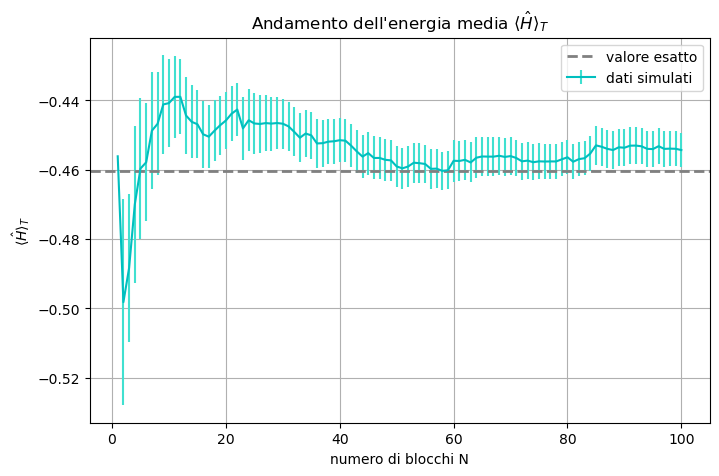

Energia minima finale E = -0.454 +/- 0.005


In [3]:
# grafico e stampa energia best

import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("Esercizio8.2/energy_best.dat")
n_block = data[:, 0]
en_best_ist = data[:,1]
en_best_prog = data[:,2]
err_best_prog = data[:,3]

plt.figure(figsize=(8,5))
plt.errorbar(n_block, en_best_prog, yerr=err_best_prog, color='c', ecolor='turquoise', label='dati simulati')
plt.axhline(y=E[0], ls='--', lw=2, color='grey', label = 'valore esatto')
plt.xlabel("numero di blocchi N")
plt.ylabel(r"$\langle \hat{H} \rangle_T$")
plt.title(r"Andamento dell'energia media $\langle \hat{H} \rangle_T$ ")
plt.grid(True)
plt.legend()
plt.show()

print(f"Energia minima finale E = {en_best_prog[-1]:.3g} +/- {err_best_prog[-1]:.1g}")

Nel grafico è riportata la stima progressiva di $\langle \hat{H} \rangle_T$ con i parametri ottimali $(\mu^*, \sigma^*)$. Il valor medio converge rapidamente verso $\langle \hat{H} \rangle_T \approx -0.454$, con barre di errore decrescenti che confermano il corretto funzionamento del data blocking. Il risultato è compatibile con il valore esatto $E_0 \approx -0.460$ quasi entro $1\sigma$. La piccola discrepanza residua è attribuibile all'intrinseca limitazione della forma funzionale di $\Psi_T^{\sigma,\mu}$, che non riproduce esattamente lo stato fondamentale, come garantito dal principio variazionale $\langle \hat{H} \rangle_T \ge E_0$.

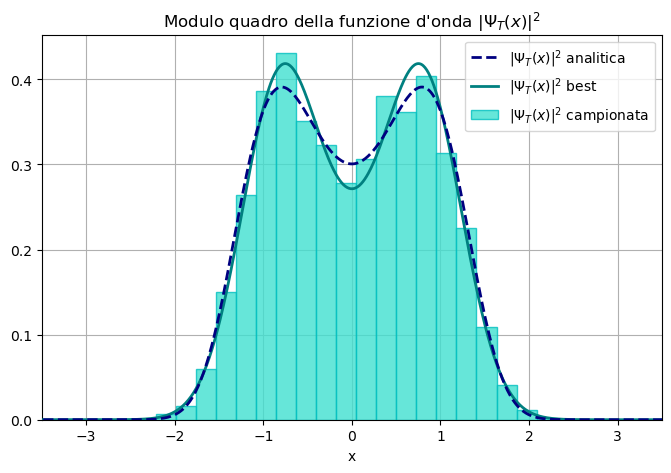

In [4]:
# grafico psi

def Psi_best(x, mu, sigma):
    return np.exp(- (x - mu)**2 / (2 * sigma**2)) + np.exp(- (x + mu)**2 / (2 * sigma**2))
          
data_best = np.loadtxt("Esercizio8.2/best_values.dat")
mu_best, sigma_best = data_best

psi_best = Psi_best(x, mu_best, sigma_best)
psi_best = psi_best**2 / np.trapezoid(psi_best**2, x) # così è normalizzata


psi_sample = np.loadtxt("Esercizio8.2/psi_sample.dat")

plt.figure(figsize=(8,5))
plt.plot(x,(psi[0])**2, color='navy', ls='--', lw=2, label = '$|\Psi_T(x)|^2$ analitica',zorder=4)
plt.plot(x,psi_best, color='teal', lw=2, label = '$|\Psi_T(x)|^2$ best', zorder=3)
plt.hist(psi_sample, bins=20, density=True, alpha=0.8, label="$|\Psi_T(x)|^2$ campionata", color="turquoise",edgecolor='c', zorder=2)
plt.title(r"Modulo quadro della funzione d'onda $|\Psi_T(x)|^2$")
plt.xlabel("x")
plt.xlim((-3.5,3.5))
plt.grid(True)
plt.legend()
plt.show()

La figura mostra il confronto tra la distribuzione campionata $|\Psi_T^{\mu^*,\sigma^*}(x)|^2$ (istogramma), la curva analitica calcolata con i parametri ottimali $(\mu^*, \sigma^*)$ (linea verde continua) e la soluzione esatta calcolata analiticamente (linea blu tratteggiata). L'istogramma segue bene l'andamento bimodale della funzione d'onda ottimizzata, con i due picchi localizzati attorno ai minimi del potenziale, confermando che il campionamento Metropolis funziona correttamente.
La lieve asimmetria visibile nell'istogramma tra il picco sinistro e quello destro si può ipotizzare che sia una fluttuazione statistica dovuta al numero finito di campioni $M=20000$.